In [1]:
import glob

import xarray as xr
import numpy as np
import intake

import dask 

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.mpl
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

import xesmf as xe

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/esmpy/__init__.py:106: DeprecationWarning: Implicit None on return values is deprecated and will raise KeyErrors.
  __author__ = msg["Author"]


In [2]:
from dask.distributed import Client
client = Client(threads_per_worker=1)
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/node.py:173: ResourceWarning: unclosed <socket.socket fd=54, family=2, type=1, proto=6, laddr=('0.0.0.0', 0)>
  if retries_left < 1:
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 37293 instead
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprec

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/37293/status,
Dashboard: /proxy/37293/status,Workers: 28
Total threads: 28,Total memory: 251.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:43665,Workers: 0
Dashboard: /proxy/37293/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:40525,Total threads: 1
Dashboard: /proxy/44915/status,Memory: 8.97 GiB
Nanny: tcp://127.0.0.1:43883,


In [3]:
#This cell must be in all notebooks!
#It allows us to run all the notebooks at once, note that the following cell has a tag "parameters" which allows us to pass in arguments externally using papermill (see mkfigs.sh for details)

#parameters

### USER EDIT start
esm_file='/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/cm3-demo-datastore.json'
dpi=300
### USER EDIT stop

import os
from matplotlib import rcParams
%matplotlib inline
rcParams['figure.dpi']= dpi

plotfolder=f"/scratch/{os.environ['PROJECT']}/{os.environ['USER']}/nesp/"
os.makedirs(plotfolder, exist_ok=True)

 # a similar cell under this means it's being run in batch
print("ESM datastore path: ",esm_file)
print("Plot folder path: ",plotfolder)

ESM datastore path:  /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/cm3-demo-datastore.json
Plot folder path:  /scratch/eg3/cxc548/nesp/


In [4]:
def detrend_1d(y, deg=1):
    x = np.arange(y.size)  
    z = np.polyfit(x, y, deg)  
    trend = np.polyval(z, x) 
    return y - trend + np.mean(y)

def detrend_monthly(da, deg=1):
    return da.groupby('time.month').apply(
        lambda x: xr.apply_ufunc(
            detrend_1d, x,
            input_core_dims=[['time']],
            output_core_dims=[['time']],
            vectorize=True,
            dask='parallelized',
            output_dtypes=[float],
            kwargs={'deg': deg}
        )
    )
    
def get_seasonal_means(da, seasons):
    da_season_mean = {}
    for season in seasons:
        if season == 'DJF':
            da_season_tmp = da.where(da['time.season'] == 'DJF')
            da_season = da_season_tmp.rolling(min_periods=3, center=True, time=3).mean()
            da_season_mean[season] = da_season.groupby('time.year').mean(dim='time')
        else:
            da_season = da.where(da['time.season'] == season, drop=True)
            da_season_mean[season] = da_season.groupby('time.year').mean(dim='time')
    return da_season_mean

def convert_units(da):
    # Convert Kelvin to Celsius
    if da.attrs.get('units') == 'K':
        da = da - 273.15
        da.attrs['units'] = '°C' 
    
    # Convert Pascal to hectoPascal
    elif da.attrs.get('units') == 'Pa':
        da = da / 100.
        da.attrs['units'] = 'hPa' 

    # Convert kg m-2 s-1 to mm/day
    elif da.attrs.get('units') == 'kg m-2 s-1':
        da = da*86400.
        da.attrs['units'] = 'mm/day' 
    return da

<span style="color: blue; font-size: 18px; font-weight: bold;">1) Read in variables 

In [5]:
import warnings
warnings.filterwarnings('ignore')


#datastore_path = "/g/data/ol01/access-om3-output/access-om3-025/MC_25km_jra_ryf-1.0-beta/experiment_datastore.json"
COLUMNS_WITH_ITERABLES = [
        "variable",
        "variable_long_name",
        "variable_standard_name",
        "variable_cell_methods",
        "variable_units"
]

datastore = intake.open_esm_datastore(
    esm_file,
    columns_with_iterables=COLUMNS_WITH_ITERABLES
)

In [6]:
def available_variables(datastore):
    """Return a pandas dataframe summarising the variables in a datastore"""
    variable_columns = [col for col in datastore.df.columns if "variable" in col]
    return (
        datastore.df[variable_columns]
        .explode(variable_columns)
        .drop_duplicates()
        .set_index("variable")
        .sort_index()
    )

In [7]:
datastore_filtered = datastore.search(realm="atmos", frequency="1mon")

for col in COLUMNS_WITH_ITERABLES:
    datastore_filtered.df[col] = datastore_filtered.df[col].astype("object").map(lambda x: list(map(str, x)))

df = available_variables(datastore_filtered)
df.index

Index(['fld_s00i004', 'fld_s00i010', 'fld_s00i012', 'fld_s00i023',
       'fld_s00i024', 'fld_s00i025', 'fld_s00i028', 'fld_s00i029',
       'fld_s00i031', 'fld_s00i032',
       ...
       'rho_level_height', 'sigma_rho', 'sigma_theta', 'sigma_theta_0',
       'sigma_theta_1', 'sigma_theta_2', 'theta_level_height',
       'theta_level_height_0', 'theta_level_height_1', 'theta_level_height_2'],
      dtype='object', name='variable', length=245)

In [8]:
ts_ds = datastore.search(variable="fld_s00i024", frequency="1mon")
    
ts = ts_ds.to_dask(
    xarray_open_kwargs={
        "chunks": "auto",
   },
    xarray_combine_by_coords_kwargs={
        'compat' : 'override',
        'data_vars': 'minimal',
        'coords': 'minimal'
    })
    
pr_ds = datastore.search(variable="fld_s05i216", frequency="1mon")
pr = pr_ds.to_dask(
    xarray_open_kwargs={
        "chunks": "auto",
   },
    xarray_combine_by_coords_kwargs={
        'compat' : 'override',
        'data_vars': 'minimal',
        'coords': 'minimal'
    })

In [9]:
print(ts)
exp_ts = convert_units(ts['fld_s00i024'].chunk({'time': -1}))
exp_pr = convert_units(pr['fld_s05i216'].chunk({'time': -1}))




# exp_ts = convert_units(xr.open_dataset("/scratch/p66/fc6164/MOPPeR/ts_Amon_ACCESS-ESM1-5_piControl_r1i1p1f1_gn_159201-209112.nc", decode_times=True).sel(time=slice('1800','2000')).ts)
# exp_pr = convert_units(xr.open_dataset("/scratch/p66/fc6164/MOPPeR/pr_Amon_ACCESS-ESM1-5_piControl_r1i1p1f1_gn_159201-209112.nc", decode_times=True).sel(time=slice('1800','2000')).pr)

# exp_ts = exp_ts.transpose('time', 'lat', 'lon')
# exp_pr = exp_pr.transpose('time', 'lat', 'lon')

<xarray.Dataset> Size: 66MB
Dimensions:                     (time: 600, lat: 144, lon: 192)
Coordinates:
  * time                        (time) datetime64[ns] 5kB 1981-01-16T12:00:00...
  * lat                         (lat) float64 1kB -89.38 -88.12 ... 88.12 89.38
  * lon                         (lon) float64 2kB 0.9375 2.812 ... 357.2 359.1
    latitude_longitude          int32 4B ...
    height                      float64 8B ...
    height_0                    float64 8B ...
    theta_level_height_1        float64 8B ...
    model_theta_level_number_1  int32 4B ...
    sigma_theta_1               float64 8B ...
Data variables:
    fld_s00i024                 (time, lat, lon) float32 66MB dask.array<chunksize=(1, 144, 192), meta=np.ndarray>
Attributes:
    Conventions:                     CF-1.6
    source:                          Data from Met Office Unified Model
    um_version:                      13.0
    intake_esm_vars:                 ['fld_s00i024']
    intake_esm_attrs:fi

In [10]:
#cm2_dir = "/g/data/fs38/publications/CMIP6/CMIP/CSIRO-ARCCSS/ACCESS-CM2/piControl/r1i1p1f1/Amon/"
cm2_dir = "/g/data/p73/archive/non-CMIP/ACCESS-CM2/cj877/history/atm/netCDF/"


#cm2_ts = convert_units(xr.open_mfdataset(cm2_dir+"*pm00*.nc",concat_dim="time",combine="nested",compat="override", data_vars="minimal", coords="minimal").fld_s00i024).chunk({'time': -1})#, 'lat': 36, 'lon': 64})
#cm2_pr = convert_units(xr.open_mfdataset(cm2_dir+"*pm00*.nc",concat_dim="time",combine="nested",compat="override", data_vars="minimal", coords="minimal").fld_s05i216).chunk({'time': -1})#, 'lat': 36, 'lon': 64})
cm2_ts = xr.open_dataset("/g/data/eg3/cxc548/nesp/ACCESS_testing/atmos_fields_cm225km_001-141.nc",decode_times=True).ts
cm2_pr = xr.open_dataset("/g/data/eg3/cxc548/nesp/ACCESS_testing/atmos_fields_cm225km_001-141.nc",decode_times=True).pr


<span style="color: blue; font-size: 18px; font-weight: bold;">2) Detrend</span>

In [11]:
exp_ts_dt = detrend_monthly(exp_ts, deg=1).compute()
exp_pr_dt = detrend_monthly(exp_pr, deg=1).compute()

In [12]:
cm2_ts_dt = detrend_monthly(cm2_ts, deg=1).compute()
cm2_pr_dt = detrend_monthly(cm2_pr, deg=1).compute()

<span style="color: blue; font-size: 18px; font-weight: bold;">3) Calculate seasonal means</span>

In [13]:
exp_ts_ann = exp_ts_dt.groupby('time.year').mean(dim='time')
exp_ts_seas = get_seasonal_means(exp_ts_dt,['DJF','JJA'])

exp_pr_ann = exp_pr_dt.groupby('time.year').mean(dim='time')
exp_pr_seas = get_seasonal_means(exp_pr_dt,['DJF','JJA'])

cm2_ts_ann = cm2_ts_dt.groupby('time.year').mean(dim='time')
cm2_ts_seas = get_seasonal_means(cm2_ts_dt,['DJF','JJA'])

cm2_pr_ann = cm2_pr_dt.groupby('time.year').mean(dim='time')
cm2_pr_seas = get_seasonal_means(cm2_pr_dt,['DJF','JJA'])

<span style="color: blue; font-size: 18px; font-weight: bold;">4) Observations comparison</span>

In [15]:
gpcp_pr = xr.open_dataset("/g/data/ct11/access-nri/replicas/esmvaltool/obsdata-v2/Tier2/GPCP-SG/OBS_GPCP-SG_atmos_2.3_Amon_pr_197901-202304.nc").pr.sel(time=slice('1979','2022'))

pr_obs_regridder = xe.Regridder(gpcp_pr, exp_pr, method='bilinear')
pr_obs_regridded = pr_obs_regridder(gpcp_pr)

pr_obs_dt = detrend_monthly(pr_obs_regridded, deg=1).compute()

pr_obs_ann = pr_obs_dt.groupby('time.year').mean(dim='time')
pr_obs_seas = get_seasonal_means(pr_obs_dt,['DJF','JJA'])

In [18]:
#dir = "/g/data/rt52/era5/single-levels/monthly-averaged/skt/*/skt_era5_moda_sfc_*.nc"
#files = glob.glob(dir)

# Filter for years 1979–2022
#filtered_files = [
#    f for f in files
#    if 1979 <= int(re.search(r'sfc_(\d{4})', f).group(1)) <= 2022
#]

#obs_ts = convert_units(xr.open_mfdataset(
#    filtered_files,
#    combine='by_coords',
#    parallel=True,
#    chunks={'time': 12}
#).skt)

# Trigger actual data load
#obs_ts.load()

#obs_ts = xr.open_dataset("/scratch/eg3/zg0866/era5_skt_1979_2022.nc").skt
obs_ts = xr.open_dataset("/g/data/ct11/access-nri/replicas/esmvaltool/obsdata-v2/Tier2/HadCRUT5/OBS_HadCRUT5_ground_5.0.1.0-analysis_Amon_tas_185001-202112.nc",decode_times=True).tas
obs_ts = obs_ts.sel(time=slice('1980','2014'))

# Regrid and compute immediately
ts_obs_regridder = xe.Regridder(obs_ts, exp_ts, method='bilinear')
ts_obs_regridded = ts_obs_regridder(obs_ts).compute()

ts_obs_dt = detrend_monthly(ts_obs_regridded, deg=1)

ts_obs_ann = ts_obs_dt.groupby('time.year').mean(dim='time')
ts_obs_seas = get_seasonal_means(ts_obs_dt,['DJF','JJA'])

<span style="color: blue; font-size: 18px; font-weight: bold;">5) Plot</span>

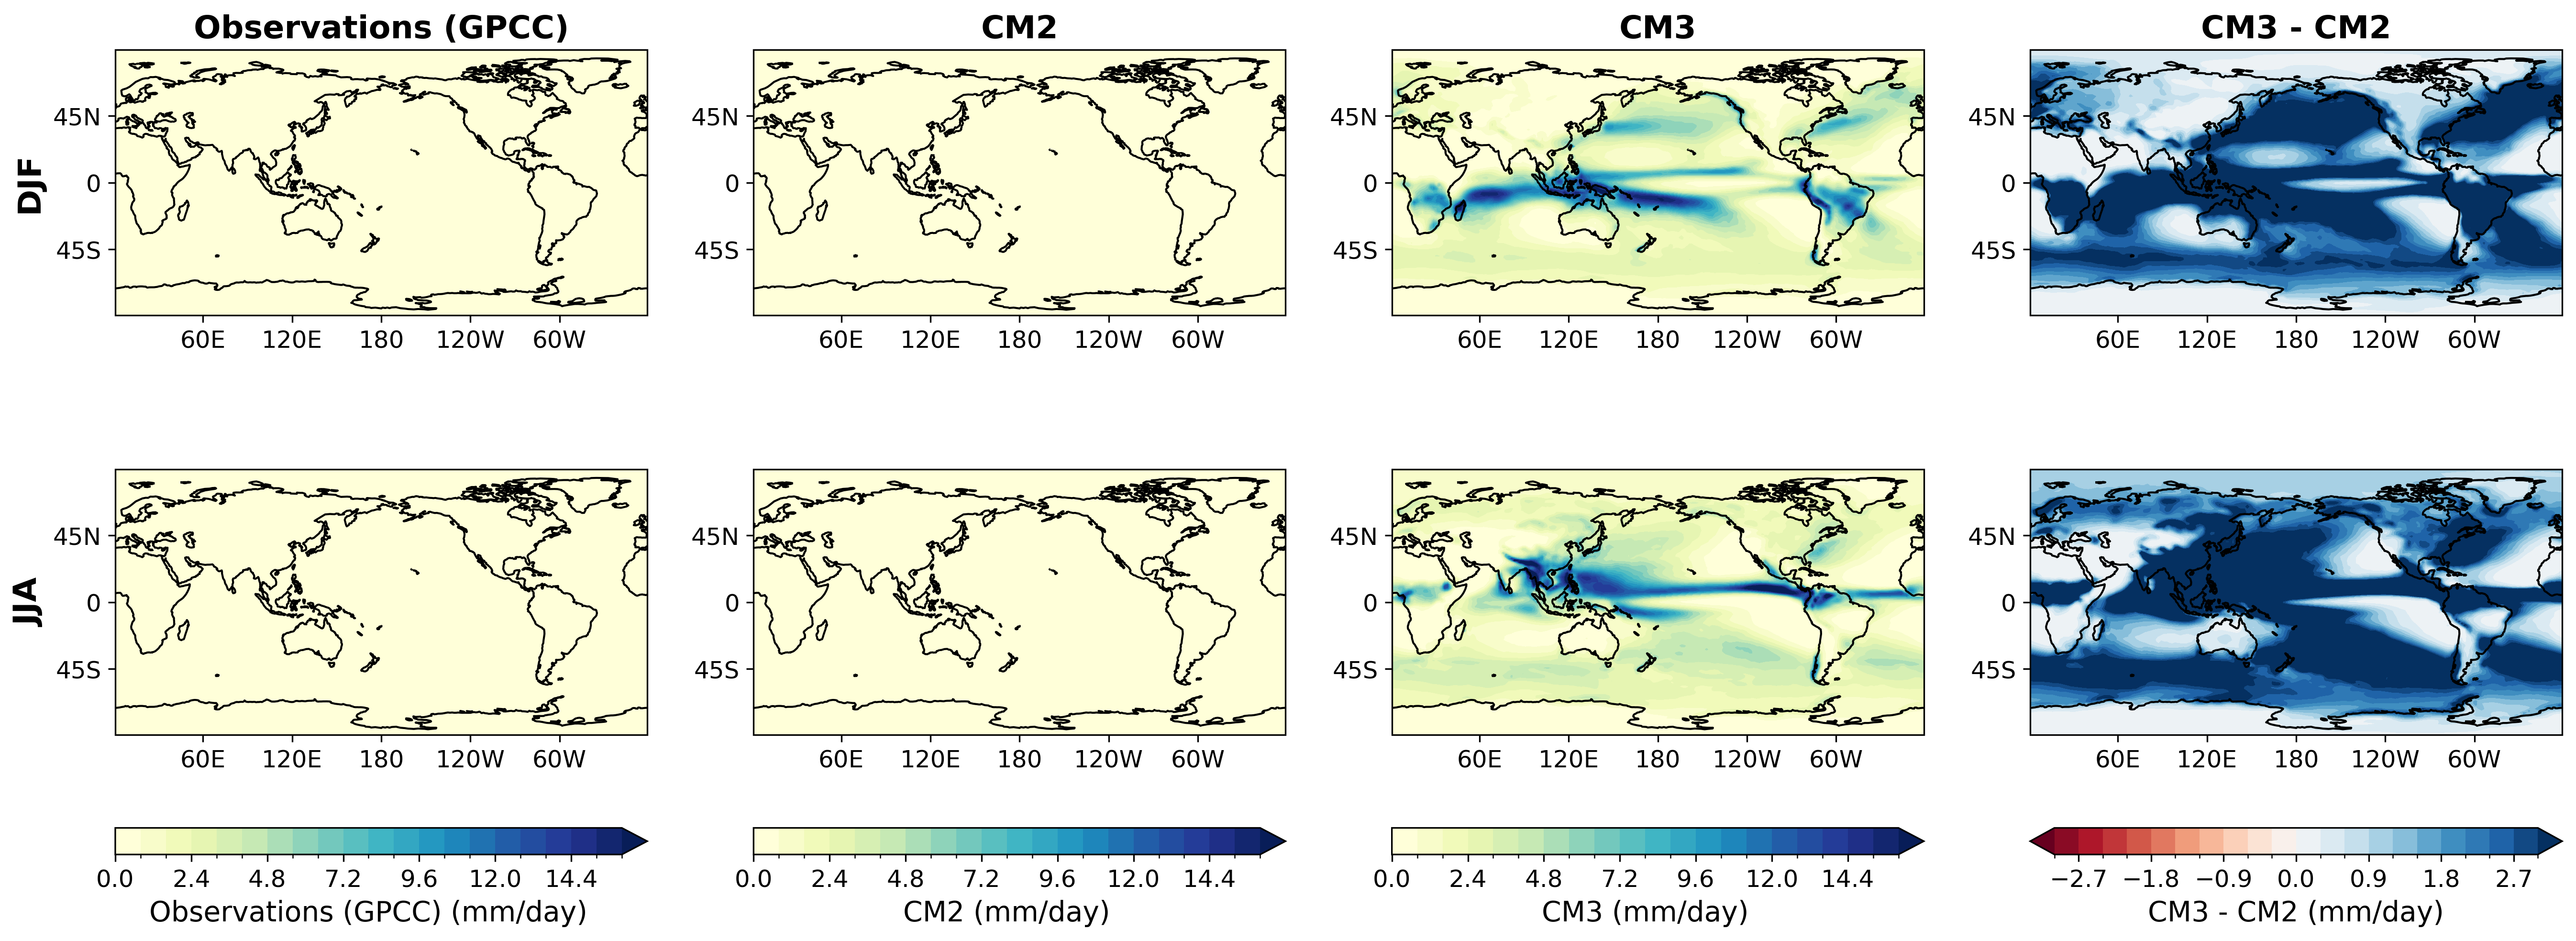

In [19]:
observations = xr.concat([pr_obs_seas['DJF'],
                         pr_obs_seas['JJA']], dim='seas')
observations['seas'] = ['DJF','JJA']

cm2 = xr.concat([cm2_pr_seas['DJF'], 
                         cm2_pr_seas['JJA']], dim='seas')
cm2['seas'] = ['DJF','JJA']

cm3 = xr.concat([exp_pr_seas['DJF'], 
                         exp_pr_seas['JJA']], dim='seas')
cm3['seas'] = ['DJF','JJA']

cmaps = [plt.get_cmap('YlGnBu'),  # Observations
         plt.get_cmap('YlGnBu'),   # CM2
         plt.get_cmap('YlGnBu'),  # CM3
         plt.get_cmap('RdBu')]   # CM3 - CM2
extend_opts = ['max', 'max', 'max', 'both']  

vmin_main, vmax_main = 0, 16
vmin_diff, vmax_diff = -3, 3
levels_main = np.linspace(vmin_main, vmax_main, 21)
levels_diff = np.linspace(vmin_diff, vmax_diff, 21)
season_labels = ['DJF', 'JJA']
column_titles = ['Observations (GPCC)', 'CM2', 'CM3', 'CM3 - CM2']
n_seasons = observations.shape[0]  

fig, ax = plt.subplots(n_seasons, 4, figsize=(22, 8), sharex=True, sharey=True,
    subplot_kw=dict(projection=ccrs.PlateCarree(central_longitude=180)))

ax = ax.reshape(n_seasons, 4)
obs_fields   = [observations[i].mean(dim='year').compute() for i in range(n_seasons)]
cm2_fields   = [cm2[i].mean(dim='year').compute() for i in range(n_seasons)]
cm3_fields   = [cm3[i].mean(dim='year').compute() for i in range(n_seasons)]
diff_fields  = [cm3_fields[i] - cm2_fields[i] for i in range(n_seasons)]
diff_fields  = [field.compute() for field in diff_fields]

fields_per_col = [obs_fields, cm2_fields, cm3_fields, diff_fields]
vmins = [vmin_main, vmin_main, vmin_main, vmin_diff]
vmaxs = [vmax_main, vmax_main, vmax_main, vmax_diff]
levels = [levels_main, levels_main, levels_main, levels_diff]

mappables = [[], [], [], []]

for i in range(n_seasons):
    for j in range(4):
        mappable = fields_per_col[j][i].plot.contourf(
            ax=ax[i, j],
            cmap=cmaps[j],
            vmin=vmins[j],
            vmax=vmaxs[j],
            levels=levels[j],
            add_colorbar=False,
            extend=extend_opts[j],
            transform=ccrs.PlateCarree()
        )

        mappables[j].append(mappable)

        if i == 0:
            ax[i, j].set_title(column_titles[j], fontsize=16, fontweight='bold')
        else:
            ax[i, j].set_title('')
        if j == 0:
            ax[i, j].set_ylabel(season_labels[i], fontsize=16, fontweight='bold')
        else:
            ax[i, j].set_ylabel('')
for row in ax:
    for axi in row:
        axi.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=True, degree_symbol=''))
        axi.yaxis.set_major_formatter(LatitudeFormatter(degree_symbol=''))
        axi.coastlines('110m')
        axi.set_xticks(np.arange(-180, 181, 60))
        axi.set_yticks(np.arange(-90, 91, 45))
        axi.set_xlabel('')
        axi.tick_params(axis='both', labelsize=12) 

plt.subplots_adjust(wspace=0.2, hspace=0.16, bottom=0.13, top=0.94)

for j in range(4):
    cbar = fig.colorbar(
        mappables[j][0],
        ax=ax[:, j],
        orientation='horizontal',
        fraction=0.06,
        pad=0.1
    )
    cbar.set_label(
        column_titles[j] + (" (mm/day)"),
        fontsize=14
    )
    cbar.ax.tick_params(labelsize=12) 
    
plt.savefig(plotfolder+"pr_obs_cm3_djf_jja.png", bbox_inches="tight", dpi=750)

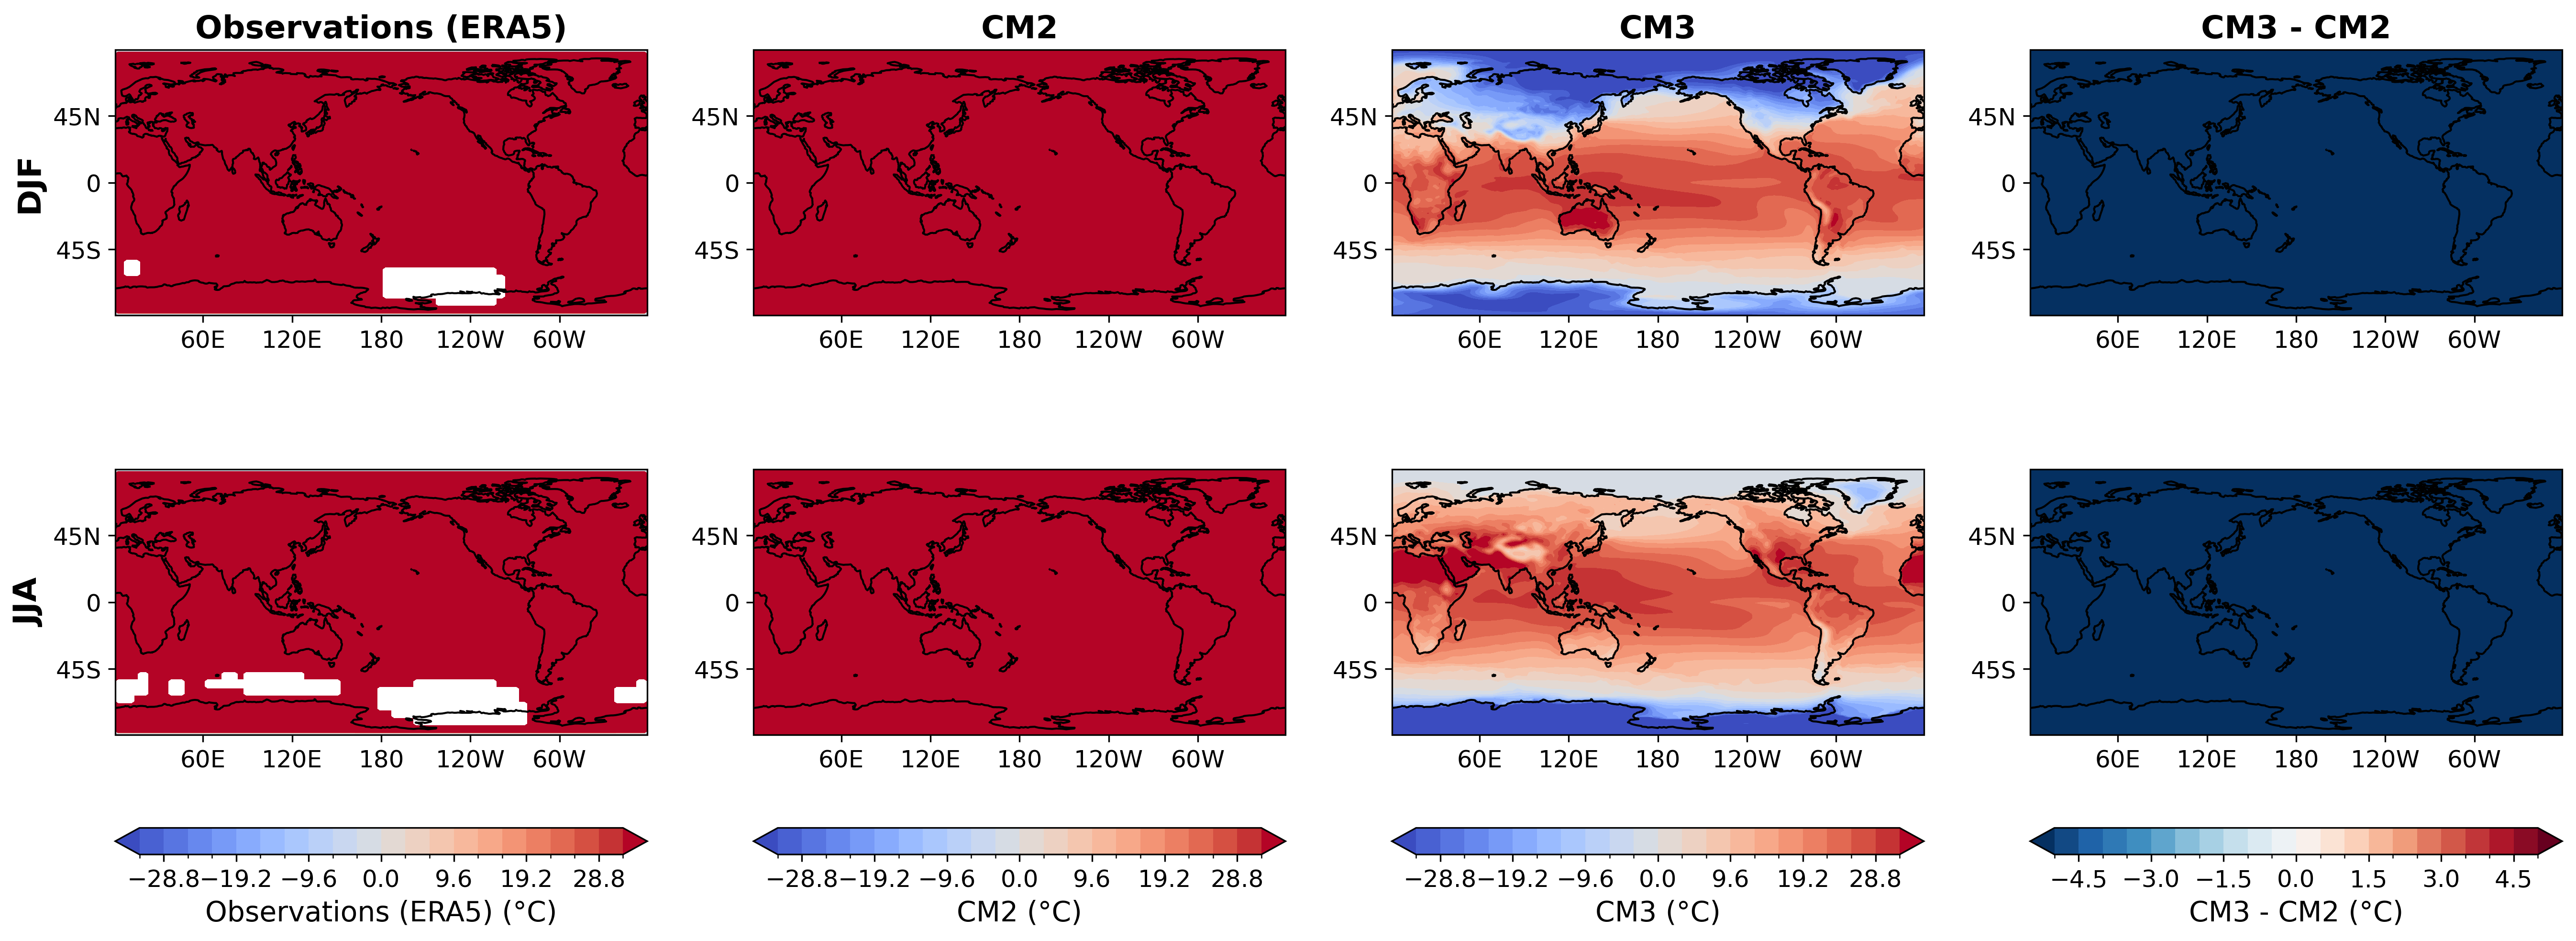

In [20]:
observations = xr.concat([ts_obs_seas['DJF'],
                         ts_obs_seas['JJA']], dim='seas')
observations['seas'] = ['DJF','JJA']

cm2 = xr.concat([cm2_ts_seas['DJF'], 
                         cm2_ts_seas['JJA']], dim='seas')
cm2['seas'] = ['DJF','JJA']

cm3 = xr.concat([exp_ts_seas['DJF'], 
                         exp_ts_seas['JJA']], dim='seas')
cm3['seas'] = ['DJF','JJA']

cmaps = [plt.get_cmap('coolwarm'),  # Observations
         plt.get_cmap('coolwarm'),   # CM2
         plt.get_cmap('coolwarm'),  # CM3
         plt.get_cmap('RdBu_r')]   # CM3 - CM2
extend_opts = ['both', 'both', 'both', 'both']  

vmin_main, vmax_main = -32, 32
vmin_diff, vmax_diff = -5, 5
levels_main = np.linspace(vmin_main, vmax_main, 21)
levels_diff = np.linspace(vmin_diff, vmax_diff, 21)
season_labels = ['DJF', 'JJA']
column_titles = ['Observations (ERA5)', 'CM2', 'CM3', 'CM3 - CM2']
n_seasons = observations.shape[0]  

fig, ax = plt.subplots(n_seasons, 4, figsize=(22, 8), sharex=True, sharey=True,
    subplot_kw=dict(projection=ccrs.PlateCarree(central_longitude=180)))

ax = ax.reshape(n_seasons, 4)
obs_fields   = [observations[i].mean(dim='year').compute() for i in range(n_seasons)]
cm2_fields   = [cm2[i].mean(dim='year').compute() for i in range(n_seasons)]
cm3_fields   = [cm3[i].mean(dim='year').compute() for i in range(n_seasons)]
diff_fields  = [cm3_fields[i] - cm2_fields[i] for i in range(n_seasons)]
diff_fields  = [field.compute() for field in diff_fields]

fields_per_col = [obs_fields, cm2_fields, cm3_fields, diff_fields]
vmins = [vmin_main, vmin_main, vmin_main, vmin_diff]
vmaxs = [vmax_main, vmax_main, vmax_main, vmax_diff]
levels = [levels_main, levels_main, levels_main, levels_diff]

mappables = [[], [], [], []]

for i in range(n_seasons):
    for j in range(4):
        mappable = fields_per_col[j][i].plot.contourf(
            ax=ax[i, j],
            cmap=cmaps[j],
            vmin=vmins[j],
            vmax=vmaxs[j],
            levels=levels[j],
            add_colorbar=False,
            extend=extend_opts[j],
            transform=ccrs.PlateCarree()
        )

        mappables[j].append(mappable)

        if i == 0:
            ax[i, j].set_title(column_titles[j], fontsize=16, fontweight='bold')
        else:
            ax[i, j].set_title('')
        if j == 0:
            ax[i, j].set_ylabel(season_labels[i], fontsize=16, fontweight='bold')
        else:
            ax[i, j].set_ylabel('')
for row in ax:
    for axi in row:
        axi.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=True, degree_symbol=''))
        axi.yaxis.set_major_formatter(LatitudeFormatter(degree_symbol=''))
        axi.coastlines('110m')
        axi.set_xticks(np.arange(-180, 181, 60))
        axi.set_yticks(np.arange(-90, 91, 45))
        axi.set_xlabel('')
        axi.tick_params(axis='both', labelsize=12) 

plt.subplots_adjust(wspace=0.2, hspace=0.16, bottom=0.13, top=0.94)

for j in range(4):
    cbar = fig.colorbar(
        mappables[j][0],
        ax=ax[:, j],
        orientation='horizontal',
        fraction=0.06,
        pad=0.1
    )
    cbar.set_label(
        column_titles[j] + (" (°C)"),
        fontsize=14
    )
    cbar.ax.tick_params(labelsize=12) 
    
plt.savefig(plotfolder+"ts_obs_cm3_djf_jja.png", bbox_inches="tight", dpi=750)